# Food Spoilage Prediction Using Environmental and Sensor Data

## Introduction
Food spoilage is a major challenge in food systems, leading to economic losses and food insecurity. This project explores how environmental factors and gas emissions influence spoilage and develops predictive models to classify food freshness.

## Research Question
How do environmental factors such as temperature and humidity influence food spoilage, and how accurately can spoilage be predicted using data-driven models?

#Import Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load Dataset

In [2]:
df = pd.read_csv("food_spoilage_dataset_2.csv")

df.head()


,Food_Name,Temperature,Humidity,Methane,CO2,Storage_Days,Spoiled
0,Chicken,17.42,84.08,137.79,1850.81,4.8,2
1,Spinach,18.27,85.98,117.61,1650.17,6.6,2
2,Beef,22.56,85.00,122.46,1960.64,6.1,2
3,Cheese,8.35,63.53,30.51,757.98,7.8,1
4,Cheese,11.47,56.15,31.61,836.51,6.0,1



The dataset contains 50,000 observations with variables including:
- Temperature
- Humidity
- Methane
- CO2
- Storage Days
- Spoilage status (target variable)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Food_Name     50000 non-null  object 
 1   Temperature   49522 non-null  float64
 2   Humidity      49510 non-null  float64
 3   Methane       49477 non-null  float64
 4   CO2           49527 non-null  float64
 5   Storage_Days  50000 non-null  float64
 6   Spoiled       50000 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 2.7+ MB


In [4]:
df.describe()

,Temperature,Humidity,Methane,CO2,Storage_Days,Spoiled
count,49522.000000,49510.000000,49477.000000,49527.000000,50000.000000,50000.000000
mean,11.370220,63.160309,44.248173,882.523123,4.542708,0.854100
std,6.739989,12.820964,44.884615,540.769590,3.312693,0.790054
min,-1.280000,32.000000,0.000000,304.680000,0.000000,0.000000
25%,5.150000,52.570000,4.680000,414.310000,2.000000,0.000000
50%,10.210000,61.630000,33.760000,754.810000,3.600000,1.000000
75%,16.887500,72.860000,62.890000,1034.145000,6.400000,1.000000
max,30.620000,100.000000,175.970000,2366.570000,15.000000,2.000000



The dataset is large and suitable for machine learning. Some missing values were identified in environmental and gas variables, reflecting real-world data collection challenges.

#Data Cleaning

In [5]:
df = df.dropna()

# Confirm changes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48069 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Food_Name     48069 non-null  object 
 1   Temperature   48069 non-null  float64
 2   Humidity      48069 non-null  float64
 3   Methane       48069 non-null  float64
 4   CO2           48069 non-null  float64
 5   Storage_Days  48069 non-null  float64
 6   Spoiled       48069 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 2.9+ MB


In [6]:
df['Spoiled'].value_counts()

,count
Spoiled,
0,19006
1,17084
2,11979


#Convert to Binary

In [7]:
df['Spoiled'] = df['Spoiled'].replace({2:1})
df['Spoiled'].value_counts()

,count
Spoiled,
1,29063
0,19006


Missing values were removed to ensure model reliability. The target variable was also converted into a binary format:
- 0 → Not spoiled
- 1 → Spoiled

#Spoilage distribution

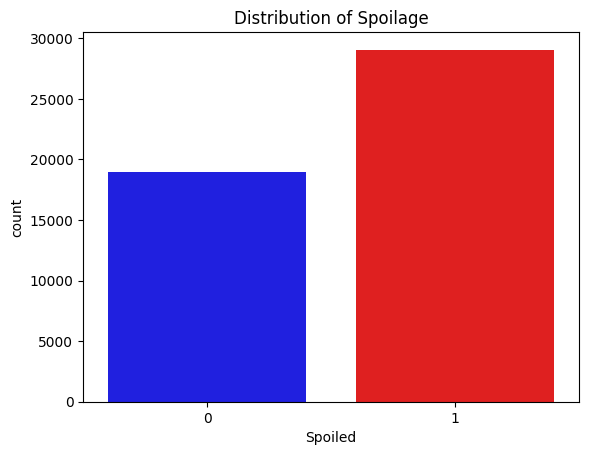

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Spoiled', data=df, hue='Spoiled', palette={0: 'blue', 1: 'red'}, legend=False)
plt.title("Distribution of Spoilage")
plt.show()

#Humidity vs Spoilage

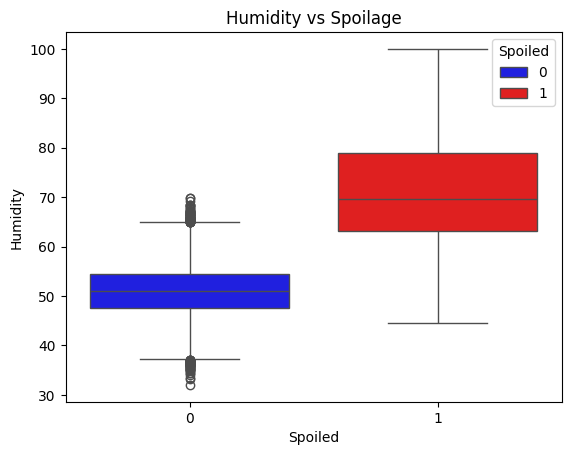

In [16]:
sns.boxplot(x='Spoiled', y='Humidity', data=df, hue='Spoiled', palette={0: 'blue', 1: 'red'})
plt.title("Humidity vs Spoilage")
plt.show()

Higher humidity levels are strongly associated with increased spoilage, likely due to enhanced microbial growth in moisture-rich environments.

#Temperature vs Spoilage

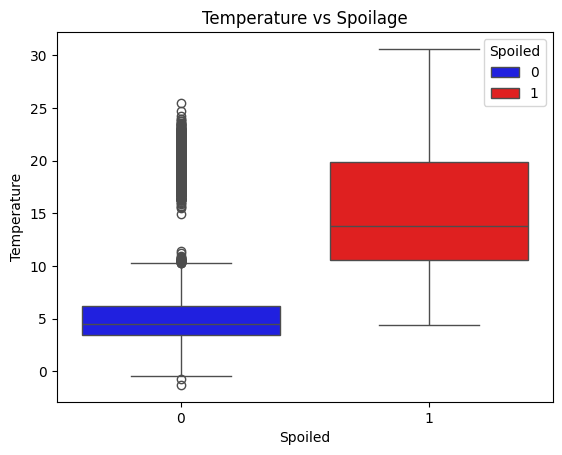

In [19]:
sns.boxplot(x='Spoiled', y='Temperature', data=df,hue='Spoiled', palette={0: 'blue', 1: 'red'})
plt.title("Humidity vs Spoilage")
plt.title("Temperature vs Spoilage")
plt.show()


Higher temperatures accelerate spoilage processes by increasing microbial and enzymatic activity.

#Methane vs Spoilage

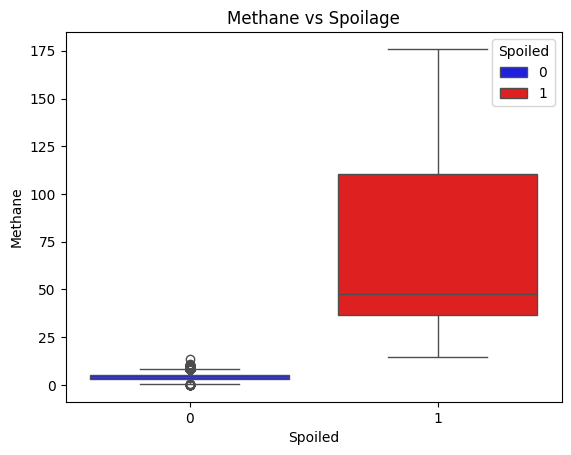

In [20]:
sns.boxplot(x='Spoiled', y='Methane', data=df,hue='Spoiled', palette={0: 'blue', 1: 'red'})
plt.title("Humidity vs Spoilage")
plt.title("Methane vs Spoilage")
plt.show()

#CO2 vs Spoilage

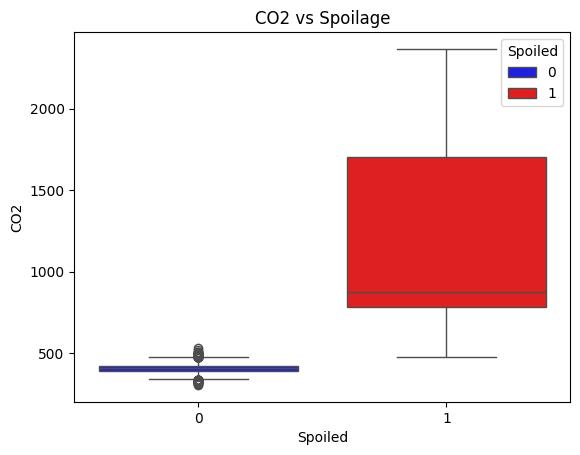

In [21]:
sns.boxplot(x='Spoiled', y='CO2', data=df,hue='Spoiled', palette={0: 'blue', 1: 'red'})
plt.title("CO2 vs Spoilage")
plt.show()

Methane and CO2 levels are significantly higher in spoiled samples, confirming their role as indicators of decomposition.



#Define Features (X) and Target (y)

In [22]:
X = df[['Temperature', 'Humidity', 'Methane', 'CO2']]
y = df['Spoiled']

#Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#FIRST MODEL (LOGISTIC REGRESSION)




In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test)

#EVALUATE MODEL

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3787
           1       1.00      1.00      1.00      5827

    accuracy                           1.00      9614
   macro avg       1.00      1.00      1.00      9614
weighted avg       1.00      1.00      1.00      9614


Confusion Matrix:
 [[3787    0]
 [   0 5827]]


Including methane and CO2 resulted in near-perfect accuracy, suggesting data leakage since these variables directly reflect spoilage. Therefore, a more realistic model was built using only environmental variables.

#Build a realistic model by removing gas variables

In [27]:
X = df[['Temperature', 'Humidity']]
y = df['Spoiled']

In [28]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.963490742666944

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      3787
           1       0.97      0.97      0.97      5827

    accuracy                           0.96      9614
   macro avg       0.96      0.96      0.96      9614
weighted avg       0.96      0.96      0.96      9614


Confusion Matrix:
 [[3611  176]
 [ 175 5652]]


The model achieved approximately 96% accuracy, demonstrating that temperature and humidity alone are strong predictors of spoilage.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)



RandomForestClassifier()

In [32]:
rf_pred = rf.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9808612440191388


The Random Forest model achieved approximately 98% accuracy, indicating the presence of nonlinear relationships between environmental factors and spoilage.

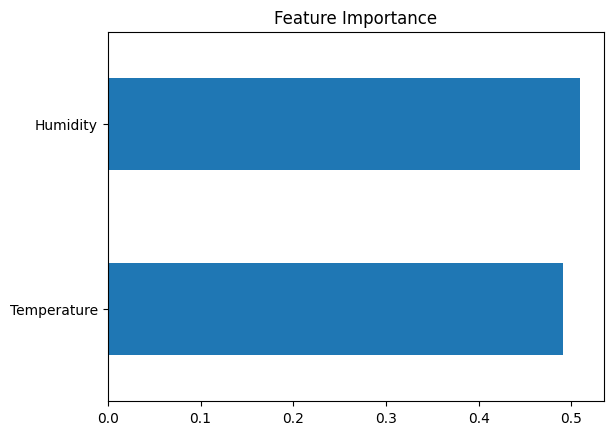

In [35]:
importance = rf.feature_importances_
features = X.columns

feat_importance = pd.Series(importance, index=features)
feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

#Insights

Environmental Drivers of Spoilage

Temperature and humidity were found to be strong predictors of food spoilage, with higher values significantly increasing the likelihood of deterioration.
Warm + moist conditions = ideal for microbial growth

Humidity as a Critical Factor

Humidity showed a strong association with spoilage, with spoiled samples consistently exhibiting higher moisture levels.
Moisture supports:
Bacterial growth
Fungal activity

Temperature Accelerates Degradation

Elevated temperatures were associated with faster spoilage rates due to increased metabolic and enzymatic activity.

Gas Emissions as Spoilage Indicators

Methane and CO₂ demonstrated near-perfect predictive power, confirming their role as direct indicators of decomposition.

Advanced insight:

These gases are byproducts of microbial metabolism
Data Leakage Awareness

The inclusion of gas variables led to near-perfect model accuracy, indicating potential data leakage, as these features directly reflect spoilage rather than predict it.

 Model Performance Insight

The Random Forest model outperformed Logistic Regression, suggesting that spoilage dynamics involve nonlinear relationships between environmental factors.

#Recommendations

Optimize Storage Conditions

Food storage systems should maintain low temperature and controlled humidity to slow microbial growth and extend shelf life.

 Integrate Sensor-Based Monitoring

Real-time monitoring using gas sensors (methane and CO₂) can provide early detection of spoilage and improve quality control systems.

 Improve Supply Chain Management

Environmental conditions should be continuously monitored during transportation to reduce spoilage and postharvest losses.

 Smart Storage Systems

Implementation of intelligent storage systems that adjust temperature and humidity dynamically can significantly reduce food waste.

 Use Predictive Models in Industry

Data-driven models can be integrated into food management systems to predict spoilage risk and optimize inventory decisions.

 Sustainability Impact

Reducing spoilage through data-driven approaches can contribute to food security and minimize environmental waste.